##Import

In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np


In [2]:
import pandas as pd
!pip install -q gdown

# Baixar os dois arquivos com nomes apropriados
!gdown --id 1qTawPpJknCQv1zo4ObYGgp-qTdbO9ncj --output metricas_grafos_pais.csv
!gdown --id 1NWvkGMZnk2UOSaVU8pvT_rNCqeLeD6js --output metricas_amostras_rede_checkpoints.csv

# Ler os arquivos
df_pais = pd.read_csv("metricas_grafos_pais.csv")[
    ["i", "graph_type", "g_n", 'grau_medio', 'grau_var', 'path_length_medio',
     'path_length_var', 'clustering_medio', 'clustering_var',
     'betweenness_medio', 'betweenness_var', 'eigenvector_medio',
     'eigenvector_var']
]

df_amostras = pd.read_csv("metricas_amostras_rede_checkpoints.csv")



/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1qTawPpJknCQv1zo4ObYGgp-qTdbO9ncj
To: /content/metricas_grafos_pais.csv
100% 18.4k/18.4k [00:00<00:00, 52.4MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1NWvkGMZnk2UOSaVU8pvT_rNCqeLeD6js
To: /content/metricas_amostras_rede_checkpoints.csv
100% 1.92M/1.92M [00:00<00:00, 96.3MB/s]


In [3]:
df_pais

,i,graph_type,g_n,grau_medio,grau_var,path_length_medio,path_length_var,clustering_medio,clustering_var,betweenness_medio,betweenness_var,eigenvector_medio,eigenvector_var
0,1,ER,500,99.9600,81.122400,1.799679,0.160192,0.200526,0.000032,0.001606,8.511913e-08,0.044538,1.634263e-05
1,2,BA,500,5.9640,49.086704,3.183142,0.516768,0.061268,0.013834,0.004384,2.770798e-04,0.028842,1.168168e-03
2,3,WS,500,6.0000,1.200000,4.458325,1.183926,0.301525,0.027676,0.006944,2.426344e-05,0.042329,2.082671e-04
3,4,ER,500,99.6040,78.611184,1.800393,0.159764,0.198855,0.000029,0.001607,8.264865e-08,0.044542,1.599677e-05
4,5,BA,500,5.9640,39.658704,3.227287,0.516453,0.054408,0.013531,0.004472,1.741504e-04,0.030388,1.076595e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71,BA,2500,5.9928,56.683148,3.826185,0.545258,0.014253,0.003634,0.001131,2.874285e-05,0.010668,2.861932e-04
71,72,WS,2500,6.0000,1.015200,5.905628,1.338083,0.321004,0.022449,0.001964,2.061434e-06,0.018844,4.490992e-05
72,73,ER,2500,500.0032,422.147990,1.799919,0.160049,0.200097,0.000001,0.000320,6.945077e-10,0.019983,6.768306e-07
73,74,BA,2500,5.9928,57.280748,3.843147,0.555918,0.015213,0.003638,0.001138,3.087317e-05,0.009892,3.021534e-04


In [4]:
df_amostras

,grau_medio,grau_var,path_length_medio,path_length_var,clustering_medio,clustering_var,betweenness_medio,betweenness_var,eigenvector_medio,eigenvector_var,id_pai,tipo,algoritmo,numero_amostra,tam_amostra,tam_rede_original,proporcao_amostra
0,1.960000,0.038400,17.000000,136.000000,0.000000,0.000000,0.333333,2.505669e-02,0.128583,0.003466,1,ER,RW,1,50,500,0.10
1,2.493333,1.049956,6.331902,4.988454,0.000000,0.000000,0.036026,1.523586e-03,0.055220,0.003617,1,ER,RW,1,150,500,0.30
2,2.776000,1.837824,5.926426,3.491711,0.001200,0.000145,0.019865,4.735907e-04,0.040822,0.002334,1,ER,RW,1,250,500,0.50
3,3.400000,3.360000,4.853033,1.694357,0.006705,0.003302,0.011072,1.721484e-04,0.037466,0.001453,1,ER,RW,1,350,500,0.70
4,1.960000,0.038400,17.000000,136.000000,0.000000,0.000000,0.333333,2.505669e-02,0.128583,0.003466,1,ER,RW,2,50,500,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,1.645714,0.668767,3.189873,5.006791,0.119429,0.086276,0.000106,7.887140e-08,0.006895,0.002810,75,WS,edgeSampling,9,350,2500,0.14
8996,1.058824,0.055363,1.000000,0.000000,0.058824,0.055363,0.000000,0.000000e+00,0.033964,0.018454,75,WS,edgeSampling,10,51,2500,0.02
8997,1.218543,0.184027,1.542857,0.791020,0.035320,0.032601,0.000045,1.271404e-08,0.012858,0.006457,75,WS,edgeSampling,10,151,2500,0.06
8998,1.505976,0.449167,2.386694,2.420114,0.108234,0.080915,0.000085,2.526538e-08,0.008904,0.003905,75,WS,edgeSampling,10,251,2500,0.10


###Análises com as métricas de médias

In [5]:
#correção para o tamanho da amostra
valores_alvo = np.array([50, 150, 250, 350])
def mais_proximo(x):
    return valores_alvo[np.argmin(np.abs(valores_alvo - x))]
df_amostras['tam_amostra'] = df_amostras['tam_amostra'].apply(mais_proximo)

/tmp/ipython-input-6-3445464767.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


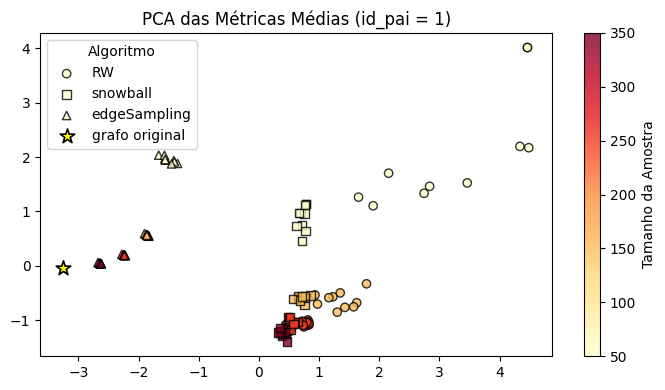

In [6]:
df_filtrado = df_amostras[df_amostras['id_pai'] == 1].copy()
df_pai = df_pais[df_pais['i'] == 1]

# Selecionar métricas médias
colunas_medias = [col for col in df_filtrado.columns if col.endswith('_medio')]
X = df_filtrado[colunas_medias]
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_filtrado['PC1'] = X_pca[:, 0]
df_filtrado['PC2'] = X_pca[:, 1]

# Configurações
algoritmos = df_filtrado['algoritmo'].unique()
marcadores = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '1']
norm = plt.Normalize(df_filtrado['tam_amostra'].min(), df_filtrado['tam_amostra'].max())
cmap = cm.get_cmap('YlOrRd')

fig, ax = plt.subplots(figsize=(7, 4))
for i, algoritmo in enumerate(algoritmos):
    df_algo = df_filtrado[df_filtrado['algoritmo'] == algoritmo]
    scatter = ax.scatter(
        df_algo['PC1'], df_algo['PC2'],
        c=df_algo['tam_amostra'],
        cmap=cmap,
        norm=norm,
        marker=marcadores[i % len(marcadores)],
        label=algoritmo,
        edgecolor='black',
        alpha=0.8
    )

# Projetar o pai no mesmo PCA
X_pai = df_pai[colunas_medias]
X_pai_scaled = StandardScaler().fit(X).transform(X_pai)  # use mesmo scaler
X_pai_pca = pca.transform(X_pai_scaled)
pc1_pai, pc2_pai = X_pai_pca[0]

# Adicionar o ponto do grafo pai (estrela amarela)
ax.scatter(
    pc1_pai, pc2_pai,
    s=120,
    c='yellow',
    marker='*',
    edgecolor='black',
    linewidth=1.2,
    label='grafo original',
    zorder=10
)

# Colorbar com a escala de cor desejada
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Tamanho da Amostra')

# Finalização
ax.set_title('PCA das Métricas Médias (id_pai = 1)')
ax.legend(title='Algoritmo', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

Números sorteados: [42, 20, 51, 7, 10, 69, 13, 47]


/tmp/ipython-input-7-3532132301.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


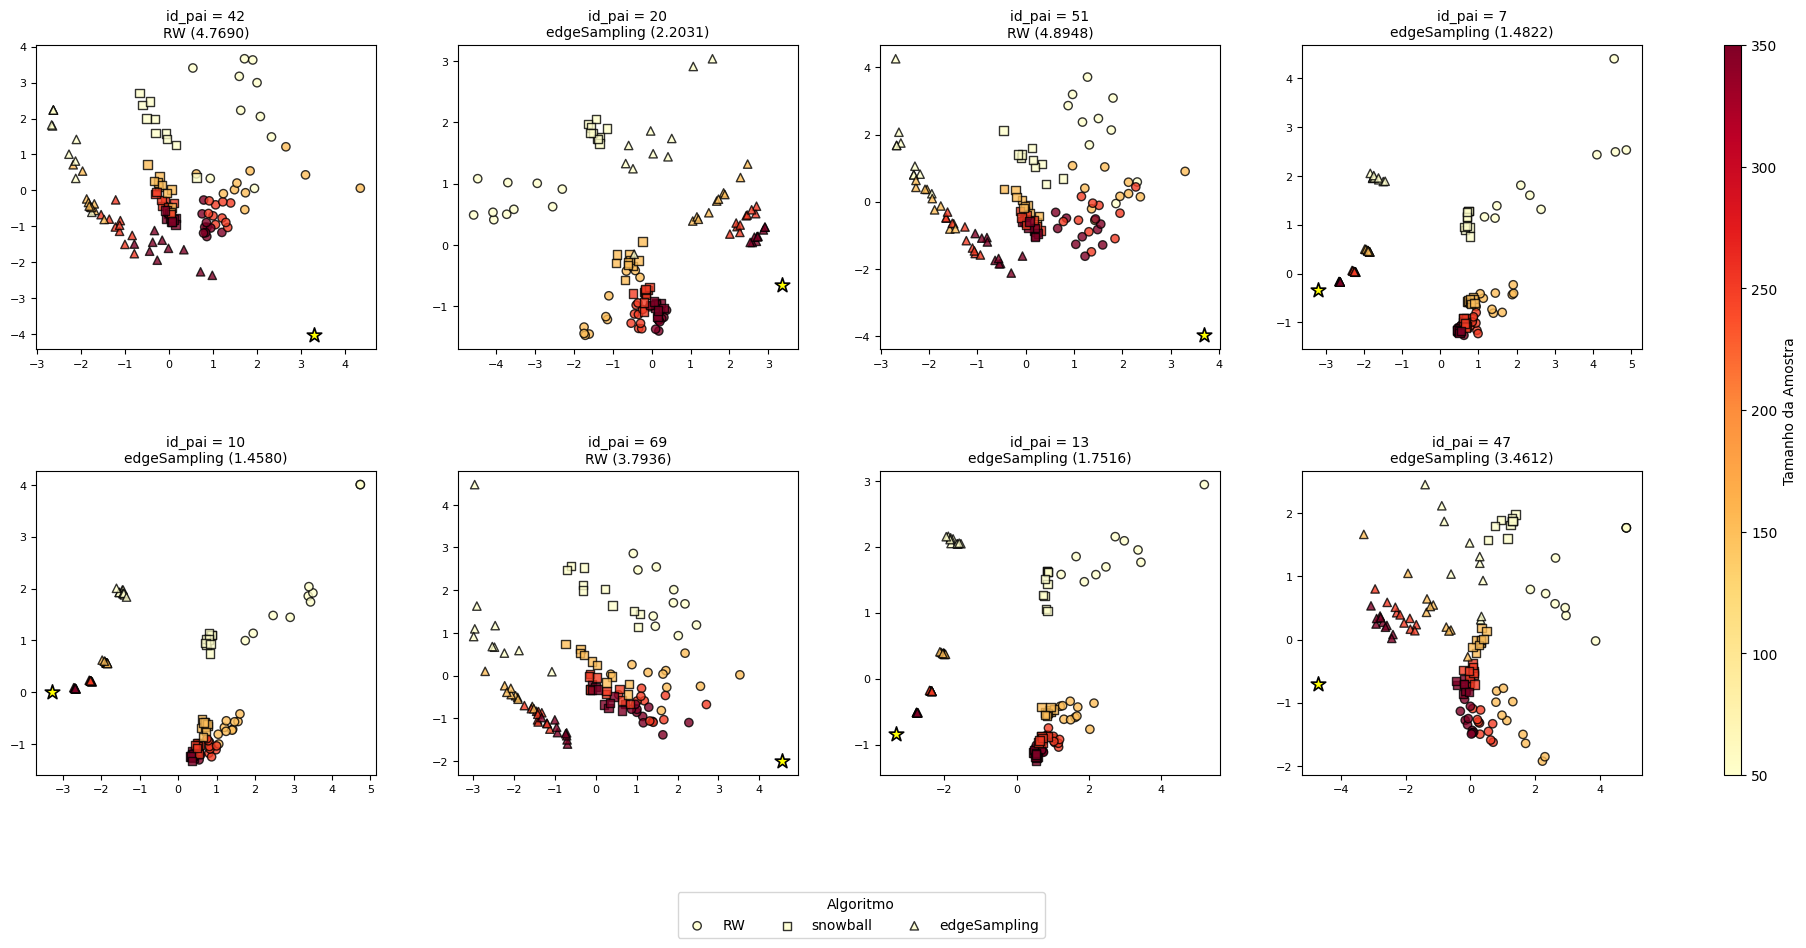

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import numpy as np
import random

# Carregar os dados
df_amostras = pd.read_csv("metricas_amostras_rede_checkpoints.csv")
df_pais = pd.read_csv("metricas_grafos_pais.csv")

# Selecionar métricas médias
colunas_medias = [col for col in df_filtrado.columns if col.endswith('_medio')]
X = df_filtrado[colunas_medias]
X_scaled = StandardScaler().fit_transform(X)

# Fixar seed e sortear 8 pais
random.seed(7)
ids_para_plotar = random.sample(range(1, 76), 8)
print("Números sorteados:", ids_para_plotar)

# Preparar grade 2x5 (última coluna é colorbar)
fig = plt.figure(figsize=(22, 10))
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.3, hspace=0.4)

# Configurações visuais
marcadores = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '1']
cmap = cm.get_cmap('YlOrRd')

# Obter limites globais para tam_amostra
all_norms = []
for id_pai in ids_para_plotar:
    df_filtro = df_amostras[df_amostras['id_pai'] == id_pai]
    if not df_filtro.empty:
        all_norms.extend(df_filtro['tam_amostra'].dropna().tolist())

vmin = min(all_norms)
vmax = max(all_norms)
if vmin == vmax:
    vmax = vmin + 1e-6
norm = plt.Normalize(vmin, vmax)

# Armazenar handles e labels para a legenda geral
legend_handles = {}
scatter_ref = None

# Plotar cada gráfico
for idx, id_pai in enumerate(ids_para_plotar):
    row = idx // 4
    col = idx % 4
    ax = fig.add_subplot(gs[row, col])

    df_filtro = df_amostras[df_amostras['id_pai'] == id_pai].copy()
    df_pai = df_pais[df_pais['i'] == id_pai]

    if (
        df_filtro.empty or df_pai.empty or
        df_filtro['tam_amostra'].dropna().nunique() == 0
    ):
        ax.set_visible(False)
        continue

    X = df_filtro[colunas_medias]
    X_pai = df_pai[colunas_medias]
    scaler = StandardScaler().fit(X)
    X_scaled = scaler.transform(X)
    X_pai_scaled = scaler.transform(X_pai)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    X_pai_pca = pca.transform(X_pai_scaled)[0]

    df_filtro['PC1'] = X_pca[:, 0]
    df_filtro['PC2'] = X_pca[:, 1]
    df_filtro['dist_estrela'] = np.linalg.norm(df_filtro[['PC1', 'PC2']].values - X_pai_pca, axis=1)

    medias = df_filtro.groupby('algoritmo')['dist_estrela'].mean()
    algoritmo_mais_proximo = medias.idxmin()
    distancia_minima = medias.min()

    for i, algoritmo in enumerate(df_filtro['algoritmo'].unique()):
        sub = df_filtro[df_filtro['algoritmo'] == algoritmo]
        sc = ax.scatter(
            sub['PC1'], sub['PC2'],
            c=sub['tam_amostra'],
            cmap=cmap,
            norm=norm,
            marker=marcadores[i % len(marcadores)],
            edgecolor='black',
            alpha=0.8,
            label=algoritmo
        )
        # Armazenar handle para legenda geral
        if algoritmo not in legend_handles:
            legend_handles[algoritmo] = sc
        if scatter_ref is None:
            scatter_ref = sc  # para a colorbar

    # Estrela do grafo pai
    ax.scatter(
        X_pai_pca[0], X_pai_pca[1],
        s=120, c='yellow', marker='*',
        edgecolor='black', linewidth=1.2, zorder=10,
        label='grafo original'
    )

    ax.set_title(f'id_pai = {id_pai}\n{algoritmo_mais_proximo} ({distancia_minima:.4f})', fontsize=10)
    ax.tick_params(labelsize=8)

# Colorbar à direita
cax = fig.add_subplot(gs[:, 4])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label='Tamanho da Amostra')

# Legenda geral abaixo
fig.legend(
    handles=list(legend_handles.values()),
    labels=list(legend_handles.keys()),
    title='Algoritmo',
    loc='lower center',
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

# Ajustar o espaço para caber a legenda geral
plt.subplots_adjust(bottom=0.15)
plt.show()


Pegando alguns exemplos, pode-se ver a predominância de EDGE Blocking e RW e, aparetemente, Edge blocking, geralmente, tem o elemento mais próximo

/tmp/ipython-input-8-2174710632.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


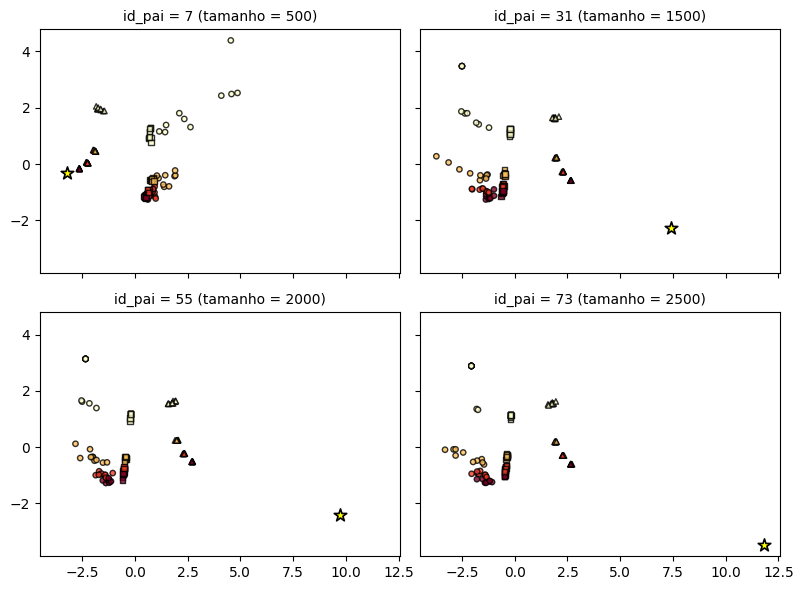

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# IDs de interesse
ids_pai = [7, 31, 55, 73]
colunas_medias = [col for col in df_amostras.columns if col.endswith('_medio')]
marcadores = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '1']
cmap = cm.get_cmap('YlOrRd')

# Normalização global da cor
tam_min = df_amostras['tam_amostra'].min()
tam_max = df_amostras['tam_amostra'].max()
norm = plt.Normalize(tam_min, tam_max)

# Subplots 2x2
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
axs = axs.flatten()

for idx, id_pai in enumerate(ids_pai):
    ax = axs[idx]

    # Filtrar amostras e pai
    df_amostras_pai = df_amostras[df_amostras['id_pai'] == id_pai].copy()
    df_pai = df_pais[df_pais['i'] == id_pai]

    if df_amostras_pai.empty or df_pai.empty:
        ax.set_title(f'id_pai = {id_pai} (sem dados)')
        continue

    # PCA com base nas amostras
    X = df_amostras_pai[colunas_medias]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df_amostras_pai['PC1'] = X_pca[:, 0]
    df_amostras_pai['PC2'] = X_pca[:, 1]

    # Projetar o grafo pai no mesmo PCA
    X_pai = df_pai[colunas_medias]
    X_pai_scaled = scaler.transform(X_pai)
    X_pai_pca = pca.transform(X_pai_scaled)
    pc1_pai, pc2_pai = X_pai_pca[0]

    # Plotar amostras
    algoritmos = df_amostras_pai['algoritmo'].unique()
    for i, algoritmo in enumerate(algoritmos):
        df_algo = df_amostras_pai[df_amostras_pai['algoritmo'] == algoritmo]
        ax.scatter(
            df_algo['PC1'], df_algo['PC2'],
            c=df_algo['tam_amostra'],
            cmap=cmap,
            norm=norm,
            s=15,
            marker=marcadores[i % len(marcadores)],
            edgecolor='black',
            alpha=0.8,
            label=algoritmo
        )

    # Plotar o ponto do grafo pai por último (destacado)
    ax.scatter(
        pc1_pai, pc2_pai,
        s=90,
        c='yellow',
        marker='*',
        edgecolor='black',
        linewidth=1.2,
        label='grafo original',
        zorder=10
    )

    g_n = int(df_pais[df_pais['i'] == id_pai]['g_n'].values[0])
    ax.set_title(f'id_pai = {id_pai} (tamanho = {g_n})', fontsize=10)


plt.tight_layout()
plt.show()


Observa-se que, de forma geral, quanto menor o tamanho do grafo pai, maior é a proximidade das amostras em relação a ele no espaço projetado. Isso sugere que redes menores tendem a gerar amostras estruturalmente mais estáveis, com menor variação nas métricas. Por outro lado, à medida que o tamanho da rede aumenta, as amostras passam a se distanciar mais do grafo original, indicando maior sensibilidade da estrutura a perturbações durante o processo de amostragem.

In [9]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionar colunas de métricas médias
metricas = [col for col in df_amostras.columns if col.endswith('_medio')]

# 2. Normalizar métricas dos filhos
scaler = StandardScaler()
df_amostras_scaled = df_amostras.copy()
df_amostras_scaled[metricas] = scaler.fit_transform(df_amostras[metricas])

# 3. Normalizar métricas dos pais com o mesmo scaler
df_pais_scaled = df_pais.copy()
df_pais_scaled[metricas] = scaler.transform(df_pais[metricas])  # usa o mesmo scaler dos filhos

# 4. Renomear colunas dos pais para diferenciar
df_pais_renomeado = df_pais_scaled[['i', 'g_n'] + metricas].copy()
renomear = {col: col + '_pai' for col in metricas}
renomear['i'] = 'id_pai'
df_pais_renomeado = df_pais_renomeado.rename(columns=renomear)

# 5. Merge entre filhos e pais
df_diff = df_amostras_scaled.merge(df_pais_renomeado, on='id_pai', how='left')

# 6. Calcular diferenças das métricas
for col in metricas:
    df_diff[col + '_diff'] = df_diff[col] - df_diff[col + '_pai']

# 7. Resultado final
df_diff = df_diff[['id_pai', 'g_n', 'tipo', 'algoritmo', 'numero_amostra', 'tam_amostra'] + [col + '_diff' for col in metricas]]
df_diff

,id_pai,g_n,tipo,algoritmo,numero_amostra,tam_amostra,grau_medio_diff,path_length_medio_diff,clustering_medio_diff,betweenness_medio_diff,eigenvector_medio_diff
0,1,500,ER,RW,1,50,-6.934897,2.457114,-2.354800,4.613325,2.613294
1,1,500,ER,RW,1,150,-6.897156,0.732628,-2.354800,0.478686,0.332146
2,1,500,ER,RW,1,250,-6.877153,0.667084,-2.340708,0.253925,-0.115569
3,1,500,ER,RW,1,350,-6.832996,0.493571,-2.276064,0.131645,-0.219920
4,1,500,ER,RW,2,50,-6.934897,2.457114,-2.354800,4.613325,2.613294
...,...,...,...,...,...,...,...,...,...,...,...
8995,75,2500,WS,edgeSampling,9,350,-0.308128,-0.427279,-2.212175,-0.025436,-0.374402
8996,75,2500,WS,edgeSampling,10,51,-0.349659,-0.781269,-2.923868,-0.026907,0.467270
8997,75,2500,WS,edgeSampling,10,151,-0.338356,-0.693517,-3.199873,-0.026281,-0.189007
8998,75,2500,WS,edgeSampling,10,251,-0.318016,-0.557112,-2.343637,-0.025720,-0.311942


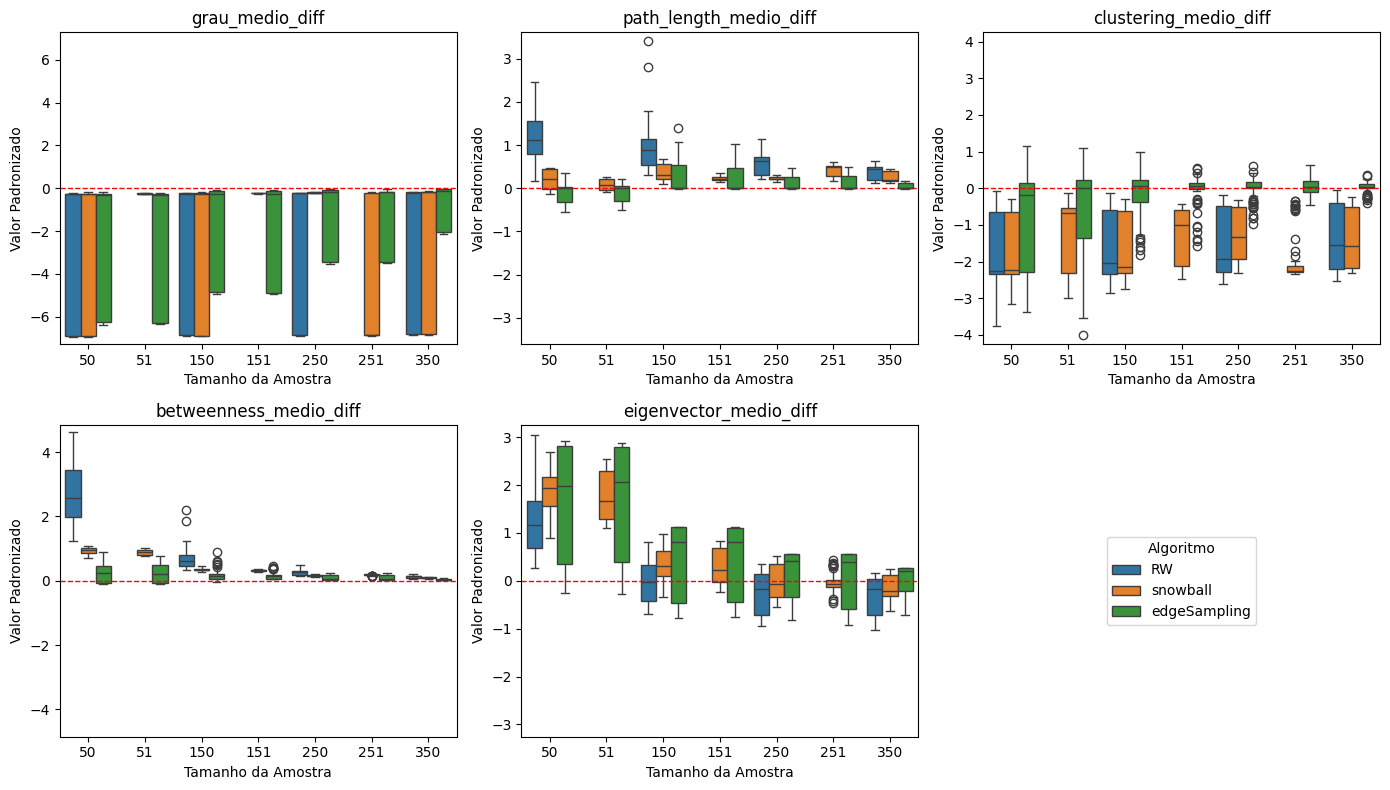

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df_diff_Nfixo = df_diff[df_diff['g_n']==500]

# Selecionar 5 métricas principais
colunas_diff = [col for col in df_diff.columns if col.endswith('_diff')]
colunas_diff = colunas_diff[:5]


# Melt
df_melt = df_diff_Nfixo.melt(
    id_vars=['tam_amostra', 'algoritmo'],
    value_vars=colunas_diff,
    var_name='métrica',
    value_name='valor'
)

# Subplots 2x3 (último ficará para legenda)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axs = axs.flatten()

for i, metrica in enumerate(colunas_diff):
    ax = axs[i]
    sns.boxplot(
        data=df_melt[df_melt['métrica'] == metrica],
        x='tam_amostra',
        y='valor',
        hue='algoritmo',
        ax=ax,
        showfliers=True
    )
    ax.set_title(metrica)
    ax.set_xlabel('Tamanho da Amostra')
    ax.set_ylabel('Valor Padronizado')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)

    # Centralizar em torno de zero
    ymin, ymax = ax.get_ylim()
    limite = max(abs(ymin), abs(ymax))
    ax.set_ylim(-limite, limite)

    # Remover legenda de cada subplot
    ax.get_legend().remove()

# Último subplot: exibir legenda
axs[-1].axis('off')  # Esconde eixos
handles, labels = axs[0].get_legend_handles_labels()
axs[-1].legend(handles, labels, title='Algoritmo', loc='center', fontsize='medium')

plt.tight_layout()
plt.show()


Acima, está sendo comparado o quanto as métricas das amostras diferem das dos grafos grafos pais, por algoritmo e tamanho da amostra. A linha vermelha em zero indica igualdade com o pai. Valores próximos de zero indicam maior fidelidade da amostragem. Nessa análise, foi usada apenas as médias em consideração.

A análise das métricas médias mostra que todos os algoritmos de amostragem introduzem distorções em relação aos grafos originais, com variações conforme a métrica e o tamanho da amostra.

- Grau médio: Todos os métodos subestimam o grau, especialmente RW e Snowball. O Edge Sampling preserva melhor a conectividade, sobretudo em amostras maiores.

- Comprimento médio do caminho: RW tende a superestimar a distância entre vértices, enquanto Snowball e Edge Sampling mantêm valores mais próximos do original conforme o tamanho da amostra aumenta.

- Clusterização média: Todos subestimam, mas o Edge Sampling é o mais fiel à estrutura de agrupamento dos grafos originais em todos os tamanhos.

- Betweenness: RW gera valores inflacionados em amostras pequenas. Snowball e Edge Sampling convergem rapidamente para valores próximos ao original com o aumento da amostra.

- Eigenvector: Todos superestimam em amostras pequenas. RW e Snowball se aproximam mais do valor original a partir de tam≥250.

Em geral, Edge Sampling aparentou ser mais representativo nessas métricas.


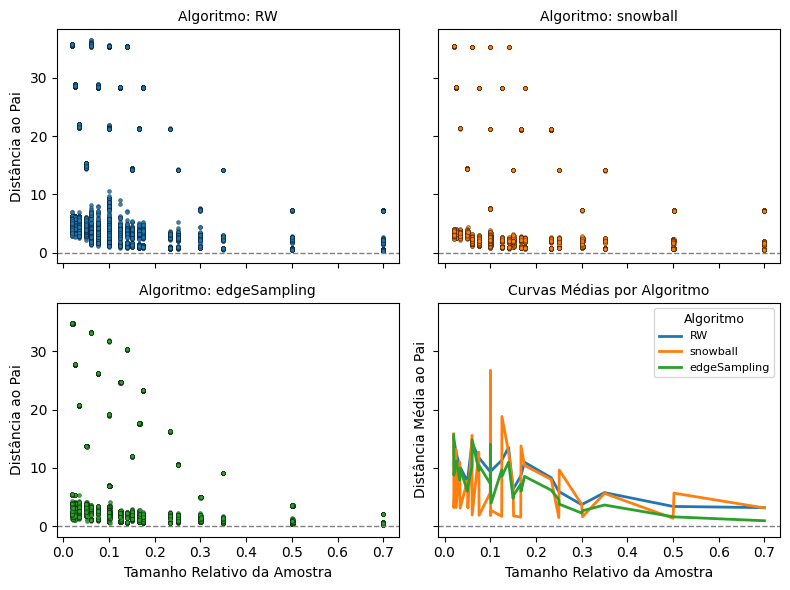

In [11]:
# 1. Selecionar colunas de diferença
colunas_diff = [col for col in df_diff.columns if col.endswith('_diff')]

# 3. Distância e tamanho relativo
df_diff['distancia'] = np.sqrt(np.sum(df_diff[colunas_diff]**2, axis=1))
df_diff['tam_relativo'] = df_diff['tam_amostra'] / df_diff['g_n']

# 4. Algoritmos
algoritmos = df_diff['algoritmo'].unique()
n_alg = len(algoritmos)

# 5. Cores padrão do seaborn
palette = sns.color_palette('tab10', n_colors=n_alg)

# 6. Subplots 2x2 (3 algoritmos + 1 para curva média)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), sharex=True, sharey=True)
axs = axs.flatten()

for i, algoritmo in enumerate(algoritmos):
    ax = axs[i]
    df_algo = df_diff[df_diff['algoritmo'] == algoritmo]

    sns.scatterplot(
        data=df_algo,
        x='tam_relativo',
        y='distancia',
        ax=ax,
        color=palette[i],
        edgecolor='black',
        alpha=0.9,
        s = 8
    )
    ax.axhline(0, linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'Algoritmo: {algoritmo}', fontsize = 10)
    ax.set_xlabel('Tamanho Relativo da Amostra')
    ax.set_ylabel('Distância ao Pai')

# 7. Último subplot: curva média
ax_media = axs[-1]
ax_media.set_title('Curvas Médias por Algoritmo', fontsize = 10)
ax_media.set_xlabel('Tamanho Relativo da Amostra')
ax_media.set_ylabel('Distância Média ao Pai')

for i, algoritmo in enumerate(algoritmos):
    df_algo = df_diff[df_diff['algoritmo'] == algoritmo]
    # Agrupar por tam_relativo e calcular média
    df_grouped = df_algo.groupby('tam_relativo')['distancia'].mean().reset_index()
    ax_media.plot(df_grouped['tam_relativo'], df_grouped['distancia'],
                  label=algoritmo, color=palette[i], linewidth=2)

ax_media.axhline(0, linestyle='--', color='gray', linewidth=1)
ax_media.legend(title='Algoritmo', fontsize=8, title_fontsize=9)  # <-- Legenda adicionada aqui

plt.tight_layout()
plt.show()


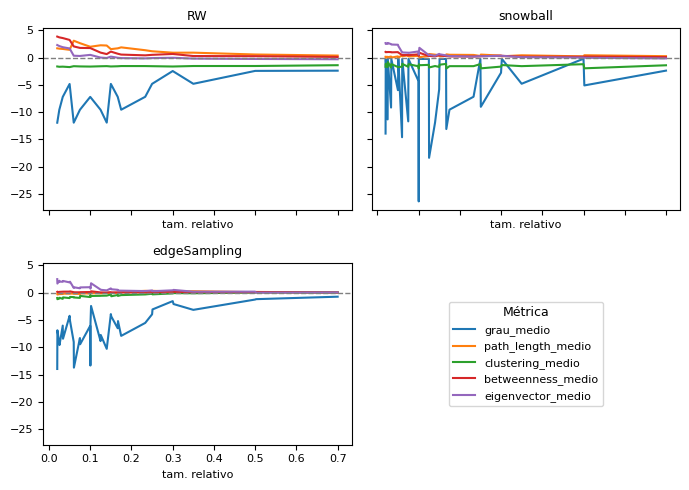

In [12]:
### USA A MÉDIA DAS DIFERENÇAS


# 1. Selecionar colunas de diferença
colunas_diff = [col for col in df_diff.columns if col.endswith('_diff')]


# 4. Algoritmos
algoritmos = df_diff['algoritmo'].unique()

# 5. Cores para as métricas
palette = sns.color_palette('tab10', n_colors=len(colunas_diff))

# 6. Subplots 2x2 com tamanho reduzido e eixos compartilhados
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(7, 5), sharex=True, sharey=True)
axs = axs.flatten()

for i, algoritmo in enumerate(algoritmos):
    ax = axs[i]
    df_algo = df_diff[df_diff['algoritmo'] == algoritmo]

    for j, metrica in enumerate(colunas_diff):
        df_grouped = df_algo.groupby('tam_relativo')[metrica].mean().reset_index()
        ax.plot(
            df_grouped['tam_relativo'],
            df_grouped[metrica],
            label=metrica.replace('_diff', ''),
            color=palette[j],
            linewidth=1.5
        )

    ax.axhline(0, linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'{algoritmo}', fontsize=9)
    ax.set_xlabel('tam. relativo', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_ylabel(None)

# Último subplot: legenda
axs[-1].axis('off')
handles, labels = axs[0].get_legend_handles_labels()
axs[-1].legend(handles, labels, title='Métrica', loc='center', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


O gráfico mostra como as métricas de rede se aproximam dos valores originais conforme o tamanho da amostra cresce relativamente. A média das diferenças é usada para cada métrica em cada tamanho relativo, com curvas mais próximas de zero indicando maior fidelidade. O método EdgeSampling se mantém mais consistente entre as métricas; RW e Snowball apresentam oscilações maiores aparentemente

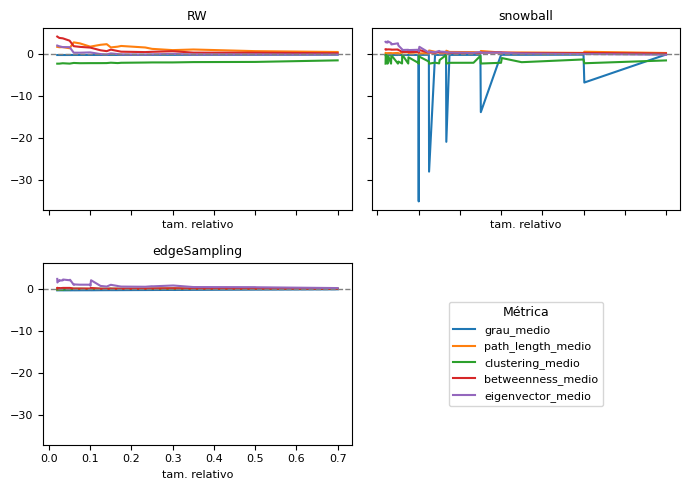

In [13]:
### USA A MEDIANA DAS DIFERENÇAS


# 1. Selecionar colunas de diferença
colunas_diff = [col for col in df_diff.columns if col.endswith('_diff')]


# 4. Algoritmos
algoritmos = df_diff['algoritmo'].unique()

# 5. Cores para as métricas
palette = sns.color_palette('tab10', n_colors=len(colunas_diff))

# 6. Subplots 2x2 com tamanho reduzido e eixos compartilhados
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(7, 5), sharex=True, sharey=True)
axs = axs.flatten()

for i, algoritmo in enumerate(algoritmos):
    ax = axs[i]
    df_algo = df_diff[df_diff['algoritmo'] == algoritmo]

    for j, metrica in enumerate(colunas_diff):
        df_grouped = df_algo.groupby('tam_relativo')[metrica].median().reset_index()
        ax.plot(
            df_grouped['tam_relativo'],
            df_grouped[metrica],
            label=metrica.replace('_diff', ''),
            color=palette[j],
            linewidth=1.5
        )

    ax.axhline(0, linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'{algoritmo}', fontsize=9)
    ax.set_xlabel('tam. relativo', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_ylabel(None)

# Último subplot: legenda
axs[-1].axis('off')
handles, labels = axs[0].get_legend_handles_labels()
axs[-1].legend(handles, labels, title='Métrica', loc='center', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


O gráfico mostra como as métricas de rede se aproximam dos valores originais conforme o tamanho da amostra cresce relativamente. A mediana das diferenças é usada para cada métrica em cada tamanho relativo, sendo que curvas próximas a zero indicam maior fidelidade do método de amostragem. O EdgeSampling é o mais estável; RW e Snowball apresentam maior variação.

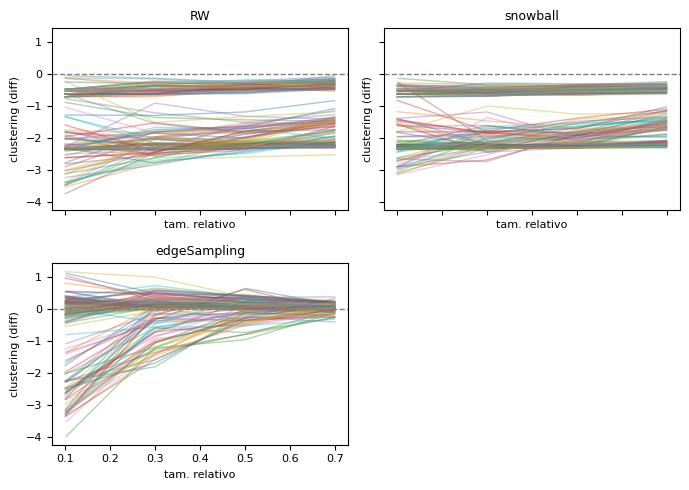

In [14]:
# 0. Filtrar apenas para g_n == 500
df_filtrado = df_diff[df_diff['g_n'] == 500]

# 1. Selecionar apenas a métrica desejada
metrica = 'clustering_medio_diff'

# 2. Obter os algoritmos únicos
algoritmos = df_filtrado['algoritmo'].unique()

# 3. Subplots 2x2 com tamanho reduzido e eixos compartilhados
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(7, 5), sharex=True, sharey=True)
axs = axs.flatten()

# 4. Para cada algoritmo, plotar curvas por (id_pai, numero_amostra)
for i, algoritmo in enumerate(algoritmos):
    ax = axs[i]
    df_algo = df_filtrado[df_filtrado['algoritmo'] == algoritmo]

    for (id_pai, numero_amostra), grupo in df_algo.groupby(['id_pai', 'numero_amostra']):
        grupo_ordenado = grupo.sort_values('tam_relativo')
        ax.plot(
            grupo_ordenado['tam_relativo'],
            grupo_ordenado[metrica],
            alpha=0.4,
            linewidth=1
        )

    ax.axhline(0, linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'{algoritmo}', fontsize=9)
    ax.set_xlabel('tam. relativo', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_ylabel('clustering (diff)', fontsize=8)

# Último subplot: apagar
axs[-1].axis('off')

plt.tight_layout()
plt.show()


Aparentemente para RW e SNOWBALL o ponto inicial afeta muito o resultado, isso pois os clusters demoram a se formar, já que o ponto atual de busca (vértice local) tende a se distanciar dos pontos já visitados durante a amostragem.
Motivo semelhante ao que foi visto pela subestimação do grau médio.

In [17]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Selecionar colunas *_diff
metricas_diff = [col for col in df_diff.columns if col.endswith('_diff')]

# Cores por tipo de grafo
cores_grafos = {
    'er': 'lightgreen',
    'ws': 'orange',
    'ba': 'skyblue'
}

# Função original, mantida igual
def calcular_vitorias_com_tipo(df_diff, df_pais, metricas_diff):
    df_resultados = []

    for tam in sorted(df_diff['tam_amostra'].unique()):
        df_tam = df_diff[df_diff['tam_amostra'] == tam].copy()

        for id_pai in df_tam['id_pai'].unique():
            df_sub = df_tam[df_tam['id_pai'] == id_pai].copy()
            graph_type_row = df_pais[df_pais['i'] == id_pai]

            if graph_type_row.empty or df_sub.empty:
                continue

            graph_type = graph_type_row['graph_type'].values[0].strip().lower()

            distancias = np.linalg.norm(df_sub[metricas_diff].values, axis=1)
            df_sub = df_sub.assign(distancia=distancias)

            medias_por_algoritmo = df_sub.groupby('algoritmo')['distancia'].mean()
            algoritmo_vencedor = medias_por_algoritmo.idxmin()

            df_resultados.append({
                'tam_amostra': tam,
                'algoritmo': algoritmo_vencedor,
                'graph_type': graph_type
            })

    return pd.DataFrame(df_resultados)

# Calcular vitórias
df_vitorias = calcular_vitorias_com_tipo(df_diff, df_pais, metricas_diff)
grupos_tamanho = [[50], [150], [250], [350]]

# Criar grid 2x2
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    f'Tamanho: {", ".join(map(str, grupo))}' for grupo in grupos_tamanho
])

# Forçar algoritmos a aparecerem
todos_algoritmos = sorted(df_vitorias['algoritmo'].unique())

for i, grupo in enumerate(grupos_tamanho):
    df_grupo = df_vitorias[df_vitorias['tam_amostra'].isin(grupo)]
    contagem = df_grupo.groupby(['algoritmo', 'graph_type']).size().unstack(fill_value=0)
    contagem.columns = contagem.columns.str.strip().str.lower()

    # Forçar todos os algoritmos a aparecer
    for alg in todos_algoritmos:
        if alg not in contagem.index:
            contagem.loc[alg] = [0] * len(contagem.columns)
    contagem = contagem.loc[todos_algoritmos]  # ordenar

    row = i // 2 + 1
    col = i % 2 + 1

    for tipo in contagem.columns:
        if tipo not in cores_grafos:
            raise ValueError(f"Tipo de grafo sem cor definida: {tipo}")

        fig.add_trace(
            go.Bar(
                x=contagem.index,
                y=contagem[tipo],
                name=tipo.upper(),
                marker_color=cores_grafos[tipo],
                showlegend=(i == 0)  # mostrar legenda só na primeira
            ),
            row=row,
            col=col
        )

# Layout geral
fig.update_layout(
    height=800,
    width=1000,
    title_text="Vitórias por Algoritmo e Tipo de Grafo",
    barmode='stack',
    legend_title='Tipo de Grafo',
    plot_bgcolor='white'
)

fig.update_xaxes(title_text="Algoritmo")
fig.update_yaxes(title_text="Vitórias")
fig.show()


O gráfico mostra o número de vitórias de cada algoritmo de amostragem (eixo x) para diferentes tamanhos de amostra (50, 150, 250, 350), segmentado por tipo de grafo original (ba, er, ws).

O algoritmo EdgeSampling se destaca amplamente, vencendo com mais frequência em todos os tamanhos e tipos de grafos. O Snowball conquista algumas vitórias apenas em grafos do tipo ws, mas perde espaço conforme o tamanho da amostra aumenta. Já o RW apresenta desempenho inferior de forma geral, sendo superado consistentemente pelos demais.

